# **Complete repository step-by-step diagnostics. (Simulation Modules)**

Speed values in this repo are km/h, and one simulation tick equals one second.

In [1]:
import yaml
from typing import Any, Callable, Optional
from utils.city_graph import CityGraph
from utils.direct_demand_sampler import DirectDemandSampler
from utils.route import RouteGenerator
from utils.travel_graph import TravelGraph
from IPython.display import Image as IPyImage, display
from rich import print 

def assert_true(condition: bool, message: str) -> bool:
    if not condition: raise AssertionError(message)
    return True

def validate_call(label: str, expected_valid: bool, func: Callable, *args: Any, **kwargs: Any) -> Optional[Any]:
    try:
        result = func(*args, **kwargs)
    except Exception as exc:
        if expected_valid:
            print(f"[bold red][EXCEPTION] {label}: Expected success but crashed with {type(exc).__name__}({exc})[/bold red]")
        else:
            print(f"[bold cyan][REJECTED] {label}: Safely blocked with {type(exc).__name__}({exc})[/bold cyan]")
        return None
    else:
        if expected_valid:
            print(f"[bold green][VALIDATED] {label}: Executed successfully.[/bold green]")
            return result
        print(f"[bold magenta][FALSE POSITIVE] {label}: Expected rejection but execution succeeded.[/bold magenta]")
        return result


In [2]:
import os
from dotenv import load_dotenv
import yaml
from utils.city_graph import CityGraph
from utils.direct_demand_sampler import DirectDemandSampler, DDMConfig
from utils.route import RouteGenerator
from utils.travel_graph import TravelGraph

load_dotenv()
TOMTOM_API_KEY = os.getenv("TOMTOM_API_KEY")

# Load configurations and instantiate baseline components.
# Speed values used later are km/h, and one update tick equals one second.
with open('configs/iligan_configs.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

city_graph_cfg = cfg["city_graph"]
city = CityGraph(
    bbox=tuple(city_graph_cfg["bbox"]),
    name=city_graph_cfg["name"],
    landmarks=city_graph_cfg["landmarks"],
    pbf_path=city_graph_cfg["pbf_path"],
    use_api=False,
    verbose=True
)

sampler = DirectDemandSampler(
    city=city,
    config=DDMConfig(**cfg["ddm"]),
    only_drivable=True
)

generator = RouteGenerator(
    city_graph=city,
    sampler=sampler
)

tg = TravelGraph(
    cg=city,
    route_generator=generator,
    config=cfg["travel_graph"],
    n_routes=20,
    n_points=5
)


[CITY GRAPH] Loading graph from binary cache.


[CITY GRAPH] Building edges: 100%|██████████| 75761/75761 [00:00<00:00, 129575.10it/s]


## **Jeep System** (in jeep.py and jeep_system.py)

[VALIDATED] Generate demo route: Executed successfully.

[VALIDATED] Spawn jeep on route: Executed successfully.

[VALIDATED] Get city bounds: Executed successfully.

[VALIDATED] Draw city map: Executed successfully.

[VALIDATED] Draw city and route: Executed successfully.

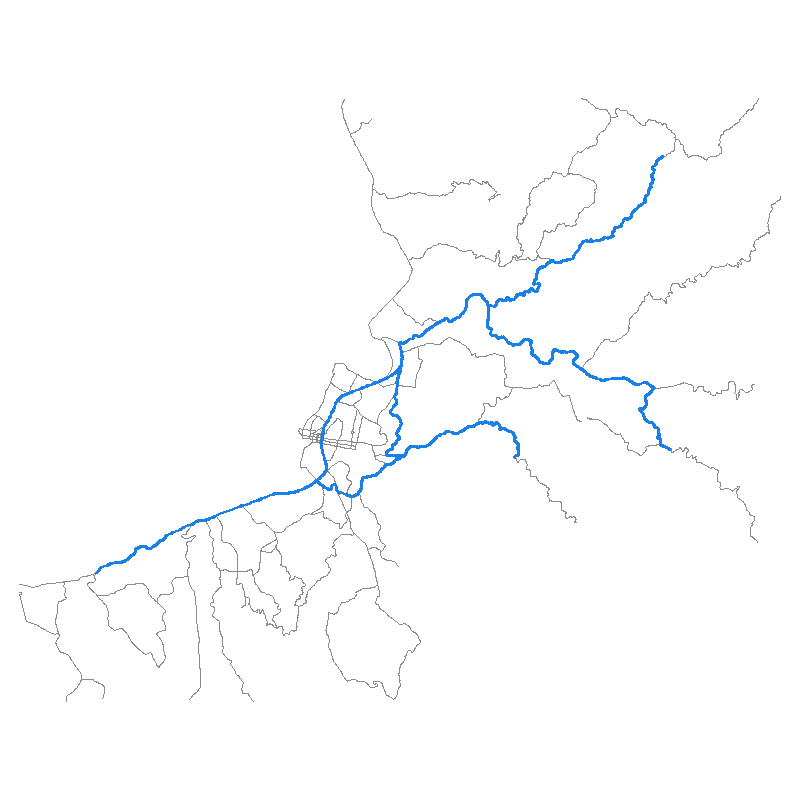

[VALIDATED] Draw city, route, and jeep: Executed successfully.

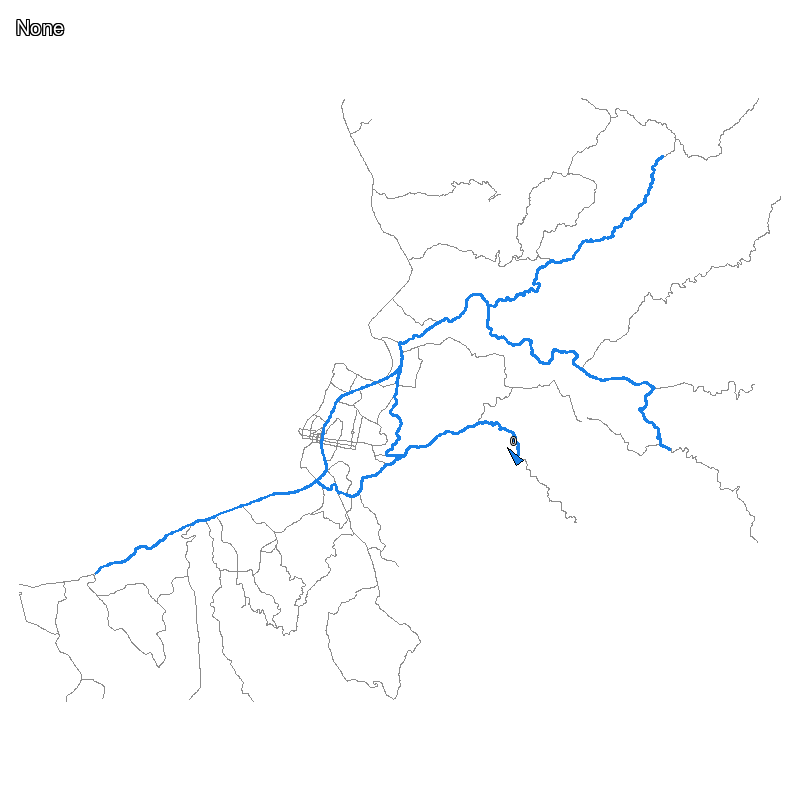

[VALIDATED] Compile jeep loop GIF: Executed successfully.

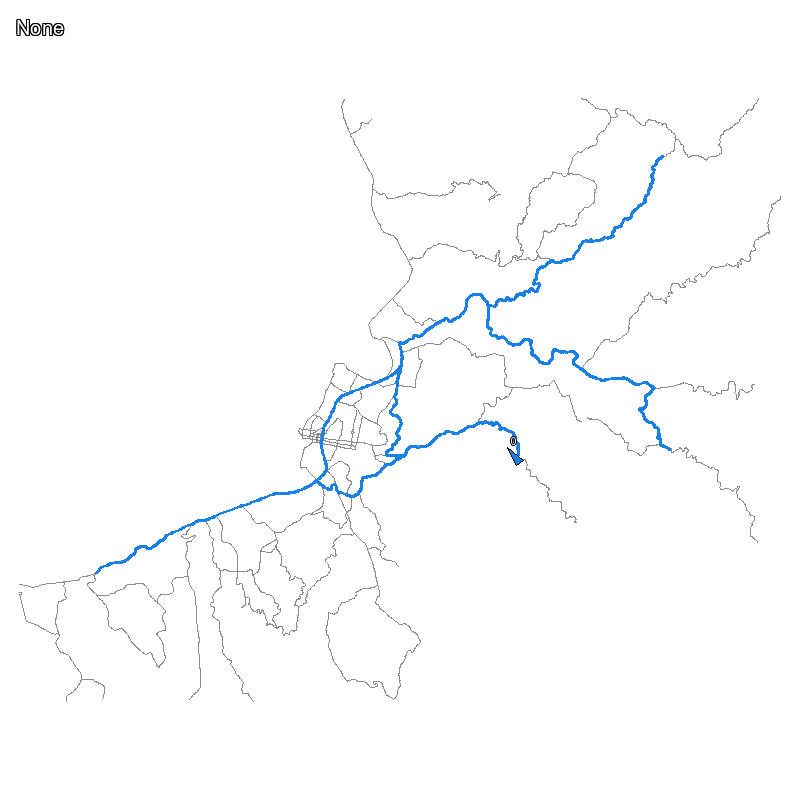

In [ ]:
import math
from IPython.display import Image as IPyImage
from utils.visualization import draw_all, compile_to_gif
from utils.jeep import Jeep

route = validate_call("Generate demo route", True, generator.generate, n_points=5)
if route:
    jeep_speed_kmh = 54.0  # km/h; one tick equals one second
    start_coord = (route.path[0].start.lon, route.path[0].start.lat)
    jeep = validate_call("Spawn jeep on route", True, Jeep, route, start_coord, jeep_speed_kmh)
    context = validate_call("Get city bounds", True, city.get_bounds)
    base_map = validate_call("Draw city map", True, city.draw, size=800, only_drivable=True)

    if route and context and base_map:
        route_frame = validate_call(
            "Draw city and route",
            True,
            draw_all,
            [route],
            context,
            base_image=base_map
        )
        if route_frame:
            display(route_frame)

    if route and jeep and context and base_map:
        initial_frame = validate_call(
            "Draw city, route, and jeep",
            True,
            draw_all,
            [route, jeep],
            context,
            base_image=base_map,
            text=str(jeep.nodes_passed_this_frame())
        )
        if initial_frame:
            display(initial_frame)

            frames = [initial_frame.copy()]
            route_length_m = sum(edge.getLength() for edge in route.path)
            meters_per_tick = jeep_speed_kmh * 1000.0 / 3600.0
            max_ticks = max(1, int(math.ceil(route_length_m / meters_per_tick)) + len(route.path) + 5)
            start_node = route.path[0].start

            frame_interval = 30
            tick = 0

            while True:
                jeep.update()
                tick += 1

                if tick % frame_interval != 0:
                    passed_nodes = jeep.nodes_passed_this_frame() or []
                    if any(node == start_node for node, _ in passed_nodes):
                        break
                    continue
                
                frame = draw_all(
                    [route, jeep],
                    context,
                    base_image=base_map,
                    text=str(f"{tick}s: No. of nodes passed this frame: {len(jeep.nodes_passed_this_frame() or [])}")
                )
                if frame is None:
                    break

                frames.append(frame)

                passed_nodes = jeep.nodes_passed_this_frame() or []
                if any(node == start_node for node, _ in passed_nodes):
                    break
                
            gif_bytes = validate_call(
                "Compile jeep loop GIF",
                True,
                compile_to_gif,
                frames,
                6,
                export_to="utils/.cache/jeep_route_loop.gif"
            )
            if gif_bytes:
                display(IPyImage(data=gif_bytes, format="gif"))